In [1]:
import sys
from pathlib import Path

import numpy as np
import networkx as nx
from bayesian_order_based_learning.metrics import *

sys.path.append(str(Path.cwd().parent / "bayesian_order_based_learning"))

In [2]:
from simulation.simulation import Simulation

/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-27 21:50:51,535	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [39]:
p = 10
sigma = np.arange(p)
np.random.shuffle(sigma)

sigma

array([7, 2, 3, 6, 8, 5, 0, 4, 9, 1])

In [40]:
sim = Simulation(sigma=sigma, n_k=1000, K_list=[1, 5, 10, 20], verbose=True)

predicted_orderings, predicted_dags, log_posteriors = sim.simulate()

true_dags = sim.get_true_dags()
true_datasets = sim.get_datasets()
true_posteriors = sim.get_true_posterior()


K=1 being computed ...



2026-08-27 21:56:24,304	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-27 21:56:24,316	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-27 21:56:24,320	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-27 21:56:24,321	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:11<00:00, 170.10it/s]



K=5 being computed ...



2026-08-27 21:56:40,233	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-27 21:56:40,244	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-27 21:56:40,248	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-27 21:56:40,249	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:16<00:00, 123.80it/s]



K=10 being computed ...



2026-08-27 21:57:01,601	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-27 21:57:01,612	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-27 21:57:01,617	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-27 21:57:01,618	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:21<00:00, 91.93it/s]



K=20 being computed ...



2026-08-27 21:57:27,780	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-27 21:57:27,790	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-27 21:57:27,795	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-27 21:57:27,796	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:39<00:00, 50.09it/s]


In [41]:
def get_adj_matrix(list_dags):
    return [nx.adjacency_matrix(dag, weight=None) for dag in list_dags]

true_adj_matrices = np.array(get_adj_matrix(true_dags[:1]))
true_adj_matrices2 = np.array(get_adj_matrix(true_dags[:5]))
true_adj_matrices3 = np.array(get_adj_matrix(true_dags[:10]))
true_adj_matrices4 = np.array(get_adj_matrix(true_dags[:20]))

predicted_adj_matrices = np.array([get_adj_matrix(dags) for dags in predicted_dags[0]])
predicted_adj_matrices2 = np.array([get_adj_matrix(dags) for dags in predicted_dags[1]])
predicted_adj_matrices3 = np.array([get_adj_matrix(dags) for dags in predicted_dags[2]])
predicted_adj_matrices4 = np.array([get_adj_matrix(dags) for dags in predicted_dags[3]])

In [42]:
hd = np.mean([hamming_distance(predicted, true_adj_matrices) for predicted in predicted_adj_matrices])
hd2 = np.mean([hamming_distance(predicted, true_adj_matrices2) for predicted in predicted_adj_matrices2])
hd3 = np.mean([hamming_distance(predicted, true_adj_matrices3) for predicted in predicted_adj_matrices3])
hd4 = np.mean([hamming_distance(predicted, true_adj_matrices4) for predicted in predicted_adj_matrices4])

In [43]:
hd, hd2, hd3, hd4

(np.float64(0.698),
 np.float64(0.95),
 np.float64(0.7787999999999999),
 np.float64(0.3668))

In [44]:
tau_star_K1 = rank_correlation(predicted_orderings[0], sigma)
tau_star_K5 = rank_correlation(predicted_orderings[1], sigma)
tau_star_K10 = rank_correlation(predicted_orderings[2], sigma)
tau_star_K20 = rank_correlation(predicted_orderings[3], sigma)

In [45]:
tau_star_K1, tau_star_K5, tau_star_K10, tau_star_K20

(np.float64(0.3116888888888881),
 np.float64(0.7396000000000009),
 np.float64(0.7965777777777776),
 np.float64(0.948888888888891))

In [30]:
def find_edges(predicted_dags, true_dags):
    common_edges = [[] for _ in true_dags]
    diff_edges = [[] for _ in true_dags]
    edges_not_counted = [[] for _ in true_dags]

    for k, dag in enumerate(true_dags):
        temp = predicted_dags[-1][k]

        for e in temp.edges():
            if e in dag.edges():
                common_edges[k].append(e)
            else:
                diff_edges[k].append(e)

        for e in dag.edges():
            if e not in temp.edges():
                edges_not_counted[k].append(e)

    return common_edges, diff_edges, edges_not_counted


In [46]:
common_edges, diff_edges, edges_not_counted = find_edges(predicted_dags[0], true_dags[:1])
print(f"Common edges: {common_edges}")
print(f"Different edges: {diff_edges}")
print(f"Unaccounted edges: {edges_not_counted}")

Common edges: [[(2, 8), (3, 4), (3, 8), (5, 4), (5, 9), (6, 8), (8, 9)]]
Different edges: [[(1, 2)]]
Unaccounted edges: [[(2, 1)]]


In [47]:
common_edges2, diff_edges2, edges_not_counted2 = find_edges(predicted_dags[1], true_dags[:5])
print(f"Common edges: {common_edges2[0]}")
print(f"Different edges: {diff_edges2[0]}")
print(f"Unaccounted edges: {edges_not_counted2[0]}")

Common edges: [(2, 1), (2, 8), (3, 4), (3, 8), (5, 4), (5, 9), (6, 8), (8, 9)]
Different edges: []
Unaccounted edges: []


In [48]:
common_edges3, diff_edges3, edges_not_counted3 = find_edges(predicted_dags[2], true_dags[:10])
print(f"Common edges: {common_edges3[0]}")
print(f"Different edges: {diff_edges3[0]}")
print(f"Unaccounted edges: {edges_not_counted3[0]}")

Common edges: [(2, 1), (2, 8), (3, 4), (3, 8), (5, 4), (5, 9), (6, 8), (8, 9)]
Different edges: []
Unaccounted edges: []


In [49]:
common_edges4, diff_edges4, edges_not_counted4 = find_edges(predicted_dags[3], true_dags[:20])
print(f"Common edges: {common_edges4[0]}")
print(f"Different edges: {diff_edges4[0]}")
print(f"Unaccounted edges: {edges_not_counted4[0]}")

Common edges: [(2, 1), (2, 8), (3, 4), (3, 8), (5, 4), (5, 9), (6, 8), (8, 9)]
Different edges: []
Unaccounted edges: []


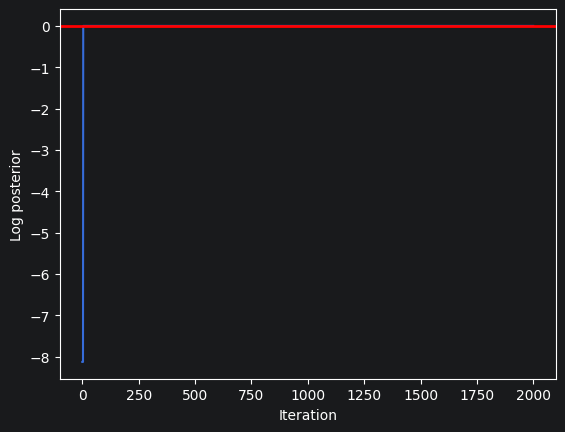

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.lineplot(x=range(20*(p**2) + 1), y=(np.array(log_posteriors[0]) - true_posteriors[0]))
ax.axhline(y=0, color="red", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Log posterior")
plt.show()

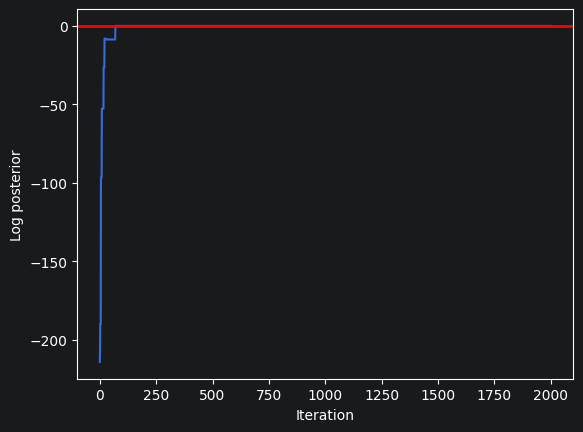

In [51]:
ax = sns.lineplot(x=range(20*(p**2) + 1), y=(np.array(log_posteriors[1]) - true_posteriors[1]))
ax.axhline(y=0, color="red", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Log posterior")
plt.show()

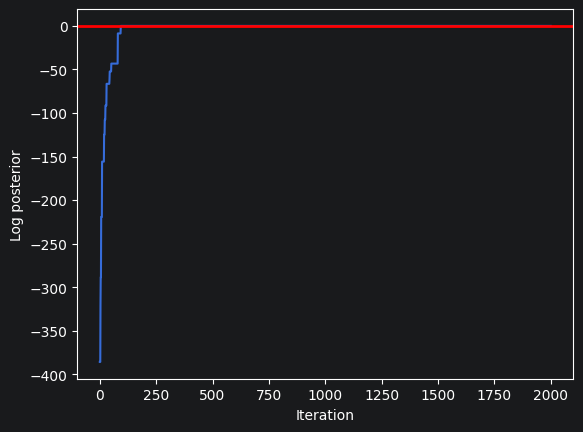

In [52]:
ax = sns.lineplot(x=range(20*(p**2) + 1), y=(np.array(log_posteriors[2]) - true_posteriors[2]))
ax.axhline(y=0, color="red", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Log posterior")
plt.show()

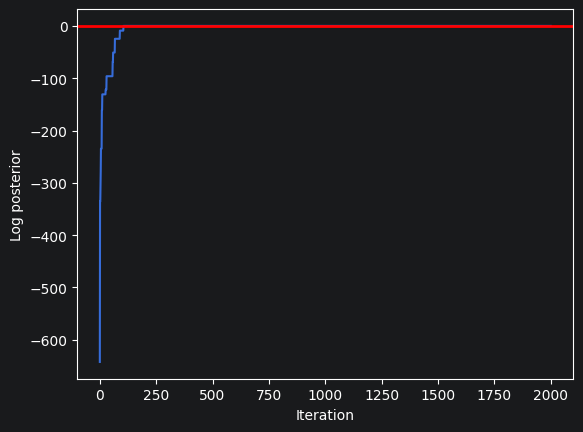

In [53]:
ax = sns.lineplot(x=range(20*(p**2) + 1), y=(np.array(log_posteriors[3]) - true_posteriors[3]))
ax.axhline(y=0, color="red", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Log posterior")
plt.show()